# 02 - Exploratory Data Analysis

## Project: Global Clinical Trial Analytics
This notebook explores trends, distributions, and patterns in global clinical trial data.

### Objectives
- 1. Analyze clinical trial trends over time
- 2. Examine phase distribution
- 3. Explore trial status distribution
- 4. Investigate enrollment patterns
- 5. Compare enrollment across phases
- 6. Analyze failure rates by phase

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("ggplot") #Switch Art Style Skins

pd.set_option("display.max_columns", None)  #展示所有列不隐藏

In [3]:
df = pd.read_csv("../data/clean/clinical_trials_clean.csv")

In [4]:
print(df.shape)

(13485, 10)


## Dataset Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13485 entries, 0 to 13484
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   NCT          13485 non-null  object
 1   Sponsor      13485 non-null  object
 2   Title        13368 non-null  object
 3   Summary      13485 non-null  object
 4   Start_Year   13485 non-null  int64 
 5   Start_Month  13485 non-null  int64 
 6   Phase        13485 non-null  object
 7   Enrollment   13485 non-null  int64 
 8   Status       13485 non-null  object
 9   Condition    13485 non-null  object
dtypes: int64(3), object(7)
memory usage: 1.0+ MB


In [6]:
round(df.describe(),1).astype(int) # describe() obly check number

,Start_Year,Start_Month,Enrollment
count,13485,13485,13485
mean,2009,6,431
std,4,3,1802
min,1984,1,0
25%,2006,4,40
50%,2009,7,124
75%,2013,10,369
max,2020,12,84496


In [7]:
df.isnull().sum()

NCT              0
Sponsor          0
Title          117
Summary          0
Start_Year       0
Start_Month      0
Phase            0
Enrollment       0
Status           0
Condition        0
dtype: int64

## Figure 1 - Clinical Trials Over Time

In [8]:
trials_per_year = (
    df.groupby("Start_Year").size().reset_index(name="trial_count")
)   #Difference between size() and count(), remember takenote

trials_per_year.head()

,Start_Year,trial_count
0,1984,1
1,1985,1
2,1988,3
3,1989,3
4,1990,3


In [9]:
trials_per_year.tail()

,Start_Year,trial_count
30,2016,517
31,2017,459
32,2018,508
33,2019,48
34,2020,2


In [10]:
print(df["Start_Year"].min())
print(df["Start_Year"].max())

1984
2020


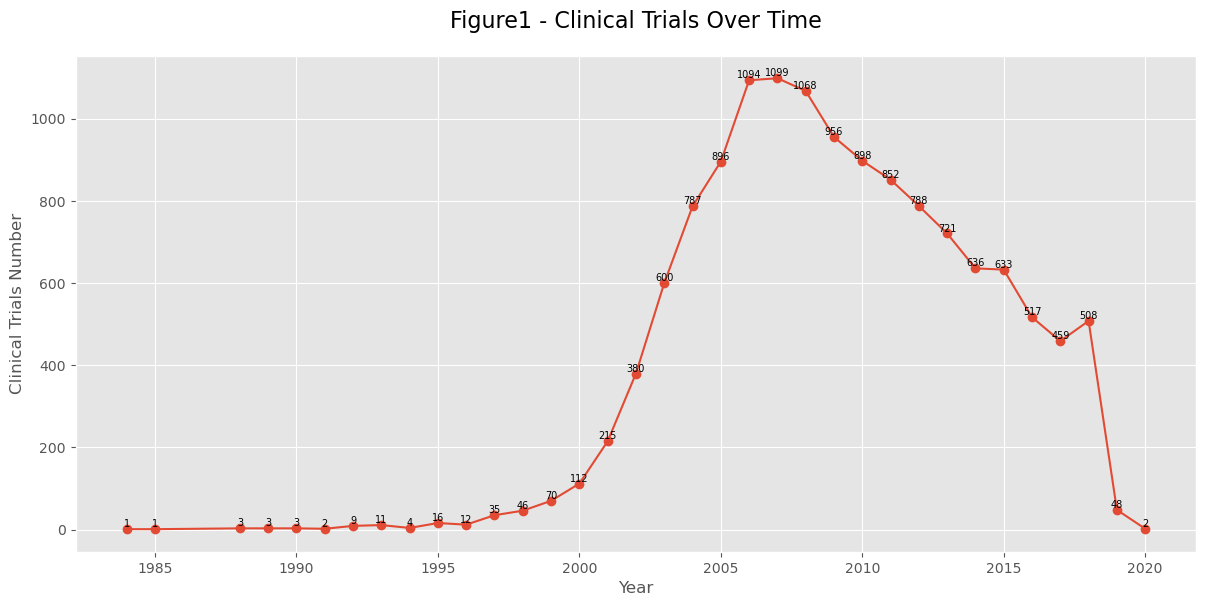

In [11]:
plt.figure(figsize=(12,6))

x = trials_per_year["Start_Year"]
y = trials_per_year["trial_count"]
plt.plot(x,y,marker="o")

for a,b in zip(x,y):
    plt.text(a, b, f"{b}", ha="center", va="bottom", size=7)

plt.title("Figure1 - Clinical Trials Over Time",fontsize=16, pad=20)

plt.xlabel("Year")
plt.ylabel("Clinical Trials Number")
plt.tight_layout(pad=0.5)

plt.show()

### Key Findings - From Figure 1

- 1. Clinical trial activity increased steadily from the late 1995s onward.
- 2. The number of registered trials grew rapidly between 2000 and 2007.
- 3. Clinical trial registrations reached a peak of over 1,000 studies per year around 2007–2008.
- 4. After the peak period, annual registrations gradually declined but remained substantially higher than pre-2000 levels.
- 5. The low counts observed in 2019–2020 are likely due to incomplete data coverage rather than an actual decline in research activity.

## Figure 2 - Clinical Trial Phase Compositionb

In [12]:
phase_counts = (
    df["Phase"].value_counts()
)

phase_counts

Phase
Phase 3            4887
Phase 2            3596
Phase 1            2516
Phase 4            2015
Phase 1/Phase 2     322
Phase 2/Phase 3     139
Early Phase 1        10
Name: count, dtype: int64

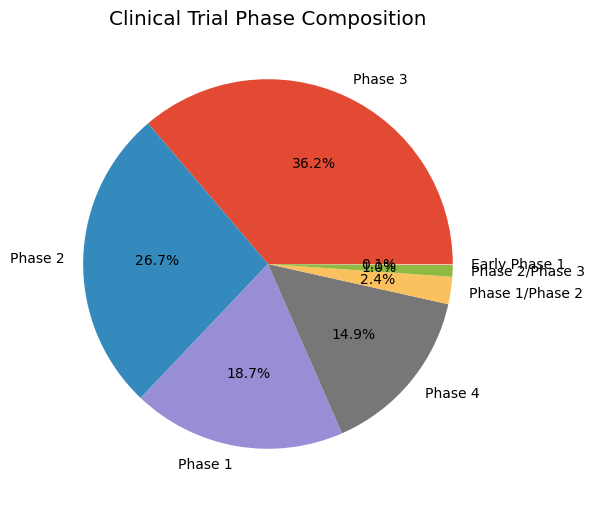

In [13]:
plt.figure(figsize=(6,6))

plt.pie(
    phase_counts,
    labels=phase_counts.index,
    autopct="%1.1f%%"
)

plt.title("Clinical Trial Phase Composition")
plt.show()

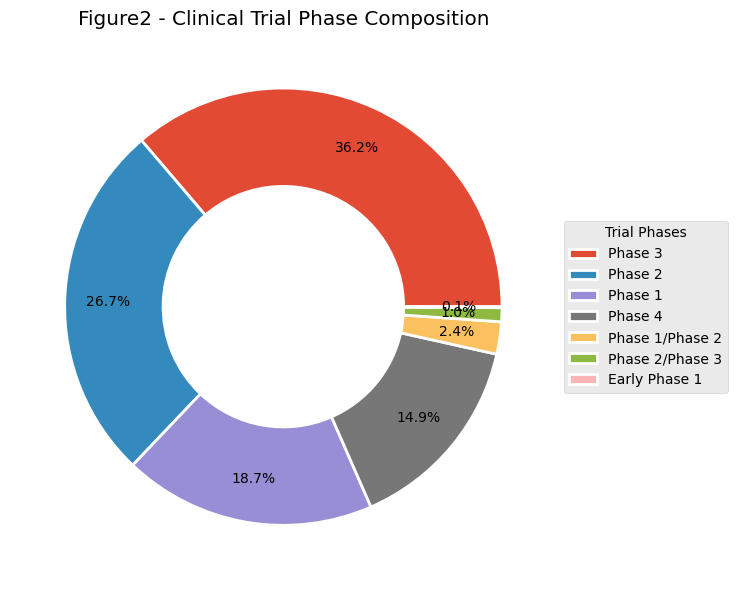

In [14]:
plt.figure(figsize=(10,6))

plt.pie(
    phase_counts,
    autopct="%1.1f%%",
    pctdistance=0.8,
    wedgeprops={'width':0.45, 'edgecolor':'white', 'linewidth':2}
)

plt.legend(
    phase_counts.index,
    title="Trial Phases",
    loc="center left",
    bbox_to_anchor=(1,0.5)
)

plt.title("Figure2 - Clinical Trial Phase Composition")
plt.tight_layout()
plt.show()

### Key Findings - From Figure2

- Phase 3 trials represent the largest share of all clinical studies, accounting for approximately one-third(36.2%) of the dataset.
- Phase 2(26.7%) and Phase 1(18.7%) studies also contribute substantial proportions of total registrations.
- Late-stage trials (Phase 3 and Phase 4) together represent more than half of all registered studies.
- Combined phases (Phase 1/2 and Phase 2/3) account for only a small fraction of total studies.

## Figure 3 - Trial Status Distribution

In [15]:
status_counts = df["Status"].value_counts().sort_values()

status_counts

Status
Enrolling by invitation       15
Suspended                     16
Unknown status                17
Not yet recruiting           107
Withdrawn                    286
Active, not recruiting       641
Recruiting                   788
Terminated                  1265
Completed                  10350
Name: count, dtype: int64

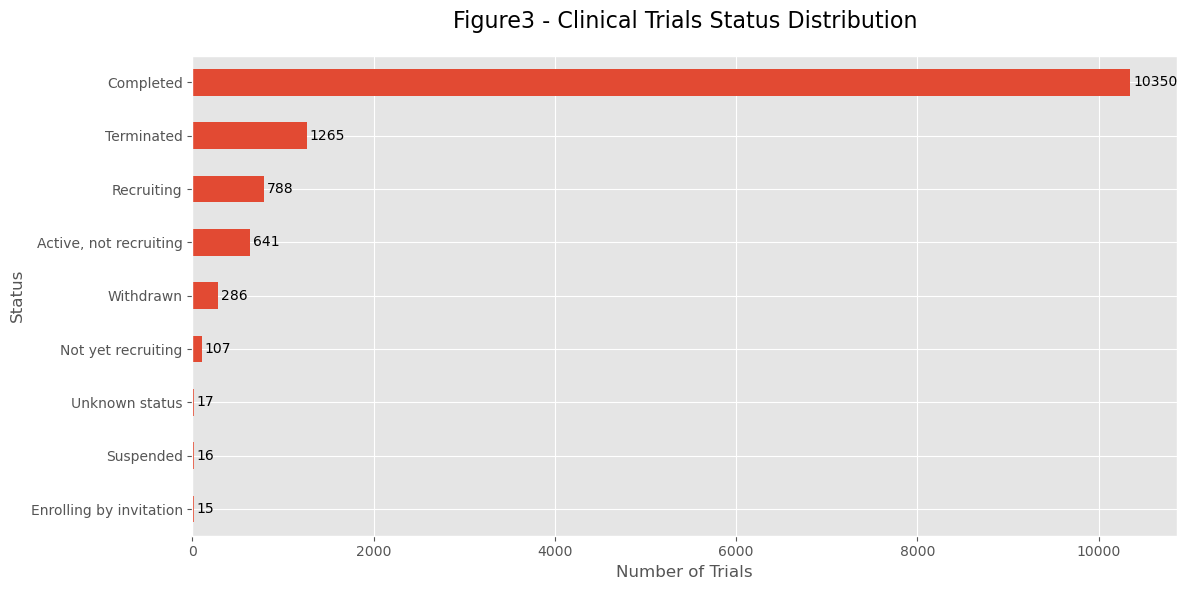

In [16]:
plt.figure(figsize=(12,6))

ax = status_counts.plot(kind="barh")

plt.title("Figure3 - Clinical Trials Status Distribution", fontsize=16, pad=20)

plt.xlabel("Number of Trials")
plt.ylabel("Status")

plt.bar_label(ax.containers[0],padding=2)

plt.tight_layout()
plt.show()

### Key Findings – From Figure 3

- Completed trials dominate the dataset, accounting for more than 75% of all registered studies.
- Terminated and Withdrawn trials account for a relatively small proportion of all clinical trials.
- A considerable number of studies are still in the Recruiting or Active stages.
- Only a small number of studies are classified as Suspended or Unknown status.
- The distribution suggests that most clinical trials successfully reach completion.

## Figure 4 - Enrollment Distribution

In [17]:
round(df["Enrollment"].describe(),2)

count    13485.00
mean       431.65
std       1802.57
min          0.00
25%         40.00
50%        124.00
75%        369.00
max      84496.00
Name: Enrollment, dtype: float64

In [18]:
import numpy as np

df["Log_Enrollment"] = np.log1p(df["Enrollment"])  # log1p(x) = ln(x+1)

round(df["Log_Enrollment"].describe(),2)

count    13485.00
mean         4.75
std          1.68
min          0.00
25%          3.71
50%          4.83
75%          5.91
max         11.34
Name: Log_Enrollment, dtype: float64

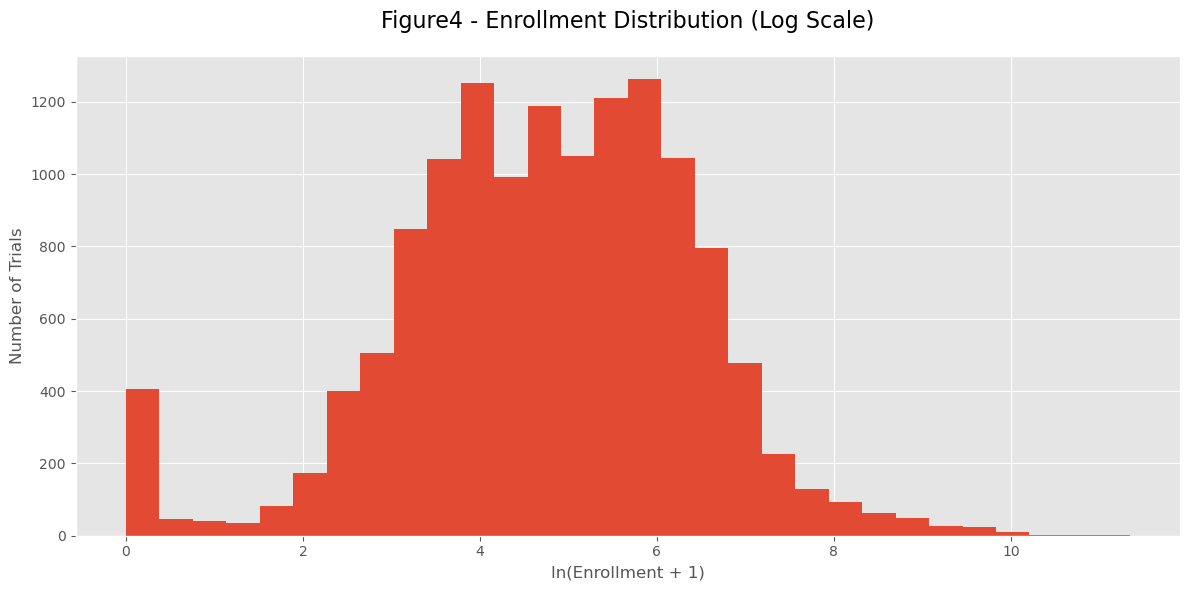

In [19]:
plt.figure(figsize=(12,6))

plt.hist(df["Log_Enrollment"],bins=30)

plt.title("Figure4 - Enrollment Distribution (Log Scale)", fontsize=16, pad=20)

plt.xlabel("ln(Enrollment + 1)")
plt.ylabel("Number of Trials")
plt.tight_layout()
plt.show()

### Key Findings – From Figure 4

- A logarithmic transformation was applied to reduce the impact of extreme outliers and improve interpretability.
- The original Enrollment variable is highly right-skewed, with a small number of exceptionally large clinical trials.
- Most clinical trials recruit relatively small to medium-sized participant groups.

## Figure 5 - Enrollment by Clinical Trial Phase

In [20]:
phase_enrollment = df[["Phase", "Enrollment"]].copy()

phase_enrollment.head()

,Phase,Enrollment
0,Phase 2,75
1,Phase 2,0
2,Phase 1/Phase 2,36
3,Phase 2,0
4,Phase 3,0


In [21]:
phase_enrollment.groupby("Phase")["Enrollment"].describe()

,count,mean,std,min,25%,50%,75%,max
Phase,,,,,,,,
Early Phase 1,10.0,58.200000,96.022914,5.0,17.25,32.0,44.50,328.0
Phase 1,2516.0,51.106916,70.893935,0.0,18.00,32.0,56.25,1260.0
Phase 1/Phase 2,322.0,99.860248,123.256851,0.0,30.00,60.0,137.50,1365.0
Phase 2,3596.0,180.114850,290.173133,0.0,38.00,90.5,210.00,4002.0
Phase 2/Phase 3,139.0,565.697842,970.302617,0.0,62.50,249.0,592.00,8031.0
Phase 3,4887.0,795.794762,2380.139229,0.0,141.00,351.0,702.50,69274.0
Phase 4,2015.0,518.169231,2672.925961,0.0,59.00,159.0,367.00,84496.0


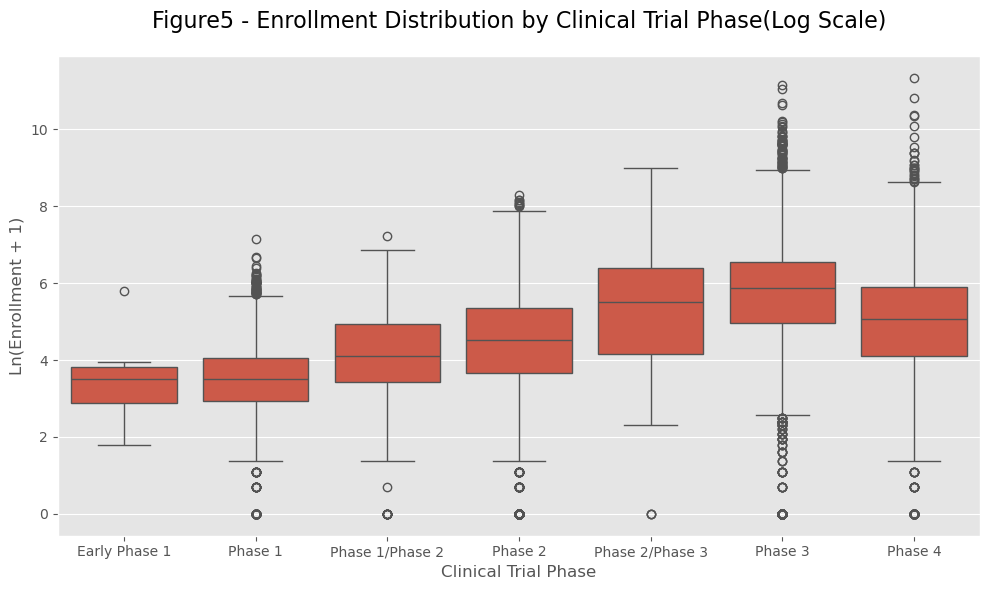

In [22]:
import seaborn as sns

plt.figure(figsize=(10,6))

phase_order = ["Early Phase 1", "Phase 1", "Phase 1/Phase 2", "Phase 2", "Phase 2/Phase 3", "Phase 3", "Phase 4"]

sns.boxplot(
    data=df,
    x="Phase",
    y="Log_Enrollment",
    order=phase_order
)

plt.title("Figure5 - Enrollment Distribution by Clinical Trial Phase(Log Scale)", fontsize=16, pad=20)
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Ln(Enrollment + 1)")

plt.tight_layout()
plt.show()

### Key Findings – From Figure 5

- Enrollment size increases significantly across successive clinical trial phases.
- Phase 3 and Phase 4 studies recruit considerably more participants than earlier-stage trials.
- Variability in enrollment expands in later phases, suggesting diverse study scales and operational complexity.
- Several large outliers appear in Phase 3 and Phase 4, representing large multinational clinical programs.
- Early-phase trials remain relatively small and concentrated, reflecting their exploratory and safety-focused nature.

## Figure 6 - Clinical Trial Failure Rate Heatmap

In [23]:
print(df["Status"].nunique())
print("")
print(df["Status"].value_counts().reset_index(name="count"))

9

                    Status  count
0                Completed  10350
1               Terminated   1265
2               Recruiting    788
3   Active, not recruiting    641
4                Withdrawn    286
5       Not yet recruiting    107
6           Unknown status     17
7                Suspended     16
8  Enrolling by invitation     15


In [24]:
df["Failed"] = df["Status"].isin(["Terminated","Withdrawn"])
df["Failed"].value_counts()

Failed
False    11934
True      1551
Name: count, dtype: int64

In [25]:
failure_rate = (
    df.groupby("Phase")["Failed"].mean().reset_index()
)

failure_rate

,Phase,Failed
0,Early Phase 1,0.000000
1,Phase 1,0.098172
2,Phase 1/Phase 2,0.139752
3,Phase 2,0.154060
4,Phase 2/Phase 3,0.172662
5,Phase 3,0.090853
6,Phase 4,0.117618


In [26]:
failure_rate["Failure_Rate(%)"] = (
    failure_rate["Failed"] * 100
).round(2)

failure_rate

,Phase,Failed,Failure_Rate(%)
0,Early Phase 1,0.000000,0.00
1,Phase 1,0.098172,9.82
2,Phase 1/Phase 2,0.139752,13.98
3,Phase 2,0.154060,15.41
4,Phase 2/Phase 3,0.172662,17.27
5,Phase 3,0.090853,9.09
6,Phase 4,0.117618,11.76


In [27]:
phase_order = ["Early Phase 1", "Phase 1", "Phase 1/Phase 2", "Phase 2", "Phase 2/Phase 3", "Phase 3", "Phase 4"]

failure_rate["Phase"] = pd.Categorical(
    failure_rate["Phase"],
    categories=phase_order,
    ordered=True
)

failure_rate = failure_rate.sort_values("Phase")

failure_rate

,Phase,Failed,Failure_Rate(%)
0,Early Phase 1,0.000000,0.00
1,Phase 1,0.098172,9.82
2,Phase 1/Phase 2,0.139752,13.98
3,Phase 2,0.154060,15.41
4,Phase 2/Phase 3,0.172662,17.27
5,Phase 3,0.090853,9.09
6,Phase 4,0.117618,11.76


In [28]:
heatmap_data = (failure_rate.set_index("Phase")[["Failure_Rate(%)"]])

heatmap_data

,Failure_Rate(%)
Phase,
Early Phase 1,0.00
Phase 1,9.82
Phase 1/Phase 2,13.98
Phase 2,15.41
Phase 2/Phase 3,17.27
Phase 3,9.09
Phase 4,11.76


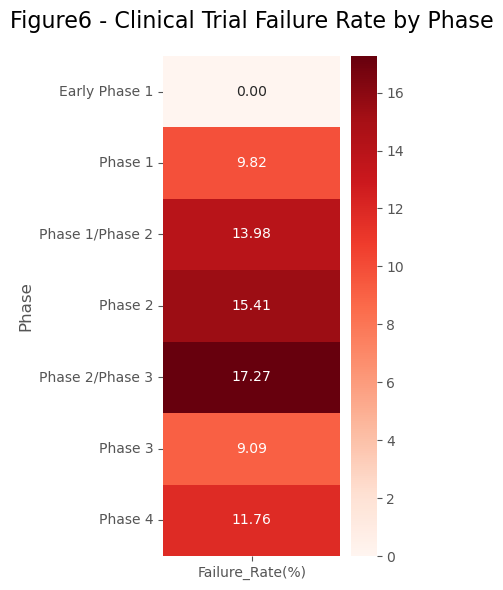

In [29]:
plt.figure(figsize=(4,6))

sns.heatmap(
    heatmap_data,
    annot=True, #Annotation
    fmt=".2f", #Format: 0.xx
    cmap="Reds" #Color Map
)

plt.title("Figure6 - Clinical Trial Failure Rate by Phase", fontsize=16, pad=20)
plt.tight_layout()

plt.show()

### Key Findings – From Figure 6

- Phase 2 and Phase 2/Phase 3 studies exhibit the highest failure rates among all development stages.
- Phase 3 trials show relatively lower failure rates despite involving larger participant populations.
- Early Phase 1 studies recorded no failed trials in this dataset, although the sample size is extremely limited.
